In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import (
    KaplanMeierFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
    GeneralizedGammaRegressionFitter,
)

df = pd.read_csv("telco.csv")
print(df.shape)
df.head()

(1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [2]:
data = df.copy()

# churn to binary
data["churn"] = (data["churn"].astype(str).str.lower() == "yes").astype(int)

# binary
for col in ["retire", "voice", "internet", "forward"]:
    data[col] = (data[col].astype(str).str.lower() == "yes").astype(int)

data["gender"]  = (data["gender"] == "Male").astype(int)        # 1=Male
data["marital"] = (data["marital"] == "Married").astype(int)    # 1=Married

# ordinal education
ed_order = {
    "Did not complete high school": 1,
    "High school degree": 2,
    "Some college": 3,
    "College degree": 4,
    "Post-undergraduate degree": 5,
}
data["ed"] = data["ed"].map(ed_order)

data = pd.get_dummies(data, columns=["region", "custcat"], drop_first=True)

data = data.drop(columns=["ID"])
data = data[data["tenure"] > 0].copy()

for c in data.columns:
    data[c] = data[c].astype(float)

print(data.dtypes)
print("churn rate:", data["churn"].mean().round(3))

tenure                   float64
age                      float64
marital                  float64
address                  float64
income                   float64
ed                       float64
retire                   float64
gender                   float64
voice                    float64
internet                 float64
forward                  float64
churn                    float64
region_Zone 2            float64
region_Zone 3            float64
custcat_E-service        float64
custcat_Plus service     float64
custcat_Total service    float64
dtype: object
churn rate: 0.274


# Kaplan Meier baseline

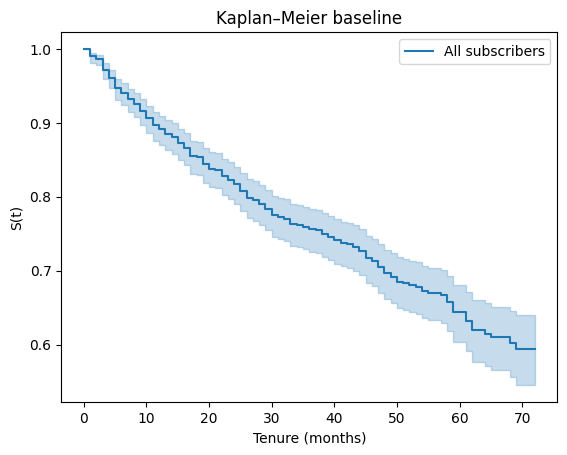

In [3]:
kmf = KaplanMeierFitter()
kmf.fit(data["tenure"], data["churn"], label="All subscribers")

ax = kmf.plot_survival_function()
ax.set_title("Kaplan–Meier baseline")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("S(t)")
plt.show()

# Fitting parametric AFT distributions

In [6]:
fitters = {
    "Weibull":          WeibullAFTFitter(),
    "LogNormal":        LogNormalAFTFitter(),
    "LogLogistic":      LogLogisticAFTFitter(),
}

results, fitted = [], {}
for name, m in fitters.items():
    try:
        m.fit(data, duration_col="tenure", event_col="churn")
        results.append({
            "model": name,
            "AIC": m.AIC_,
            "log_likelihood": m.log_likelihood_,
            "concordance": m.concordance_index_,
        })
        fitted[name] = m
    except Exception as e:
        print(f"{name} failed: {e}")

cmp = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
print(cmp.round(3))

         model       AIC  log_likelihood  concordance
0    LogNormal  2949.039       -1457.519        0.787
1  LogLogistic  2950.829       -1458.414        0.787
2      Weibull  2961.693       -1463.846        0.785


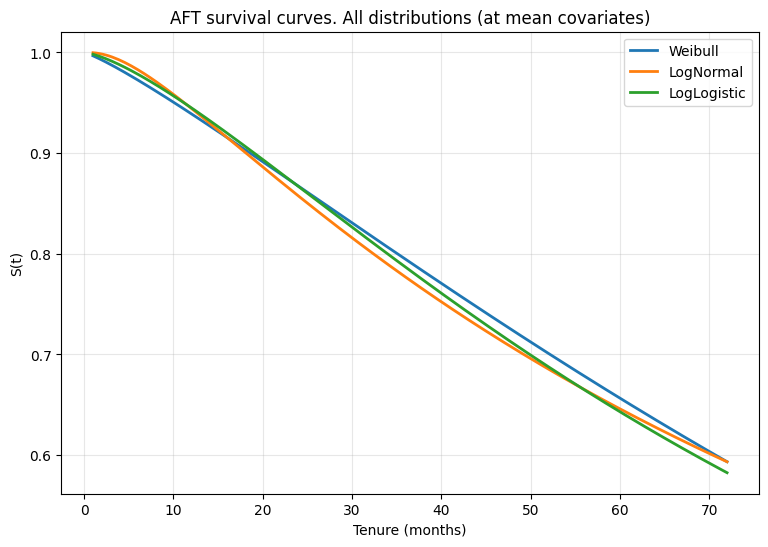

In [7]:
plt.figure(figsize=(9, 6))
times = np.linspace(1, data["tenure"].max(), 200)
mean_row = data.drop(columns=["tenure", "churn"]).mean().to_frame().T

for name, m in fitted.items():
    sf = m.predict_survival_function(mean_row, times=times)
    plt.plot(times, sf.values.ravel(), label=name, lw=2)

plt.title("AFT survival curves. All distributions (at mean covariates)")
plt.xlabel("Tenure (months)"); plt.ylabel("S(t)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Decision: LogNormal AFT.

### Comparison Table

| Model | AIC | Log-likelihood | Concordance |
|---|---|---|---|
| **LogNormal** | **2949.04** | **−1457.52** | **0.787** |
| LogLogistic | 2950.83 | −1458.41 | 0.787 |
| Weibull | 2961.69 | −1463.85 | 0.785 |
| GeneralizedGamma | failed to converge | — | — |

### Why LogNormal

**1. Best statistical fit.** Lowest AIC across all converged models. The gap to Weibull (ΔAIC ≈ 12.7) is large enough to count as strong evidence, ΔAIC > 10 indicates strong support for the lower-AIC model. LogNormal vs LogLogistic differ by only 1.8 AIC but LogNormal is still on top.

**2. Highest concordance** (0.787, tied with LogLogistic, still above Weibull's 0.785). A concordance of ~0.79 is solid ranking ability for survival on a real subscriber dataset.

**3. Interpretability for the business.** AFT coefficients exponentiate to **time ratios**, a coefficient with `exp(β) = 0.6` means the group's expected lifetime is 60% of the baseline's. That's a number a marketing manager can act on, with no hazard-ratio gymnastics needed.

### Conclusion

I select **LogNormal AFT** as the final model and proceed to feature selection in the next step.

In [8]:
FINAL = LogNormalAFTFitter

full = FINAL().fit(data, duration_col="tenure", event_col="churn")
print(full.summary[["coef", "exp(coef)", "p"]].round(4))

mu = full.summary.loc["mu_"]
keep = mu[(mu["p"] < 0.05) & (mu.index != "Intercept")].index.tolist()
print("kept:", keep)

final_data = data[keep + ["tenure", "churn"]].copy()
final = FINAL().fit(final_data, duration_col="tenure", event_col="churn")

print(final.summary[["coef", "exp(coef)", "p"]].round(4))
print("AIC:", round(final.AIC_, 2),
      " concordance:", round(final.concordance_index_, 3))

                                coef  exp(coef)       p
param  covariate                                       
mu_    address                0.0427     1.0436  0.0000
       age                    0.0325     1.0330  0.0000
       custcat_E-service      1.0722     2.9217  0.0000
       custcat_Plus service   0.9209     2.5116  0.0000
       custcat_Total service  1.1833     3.2651  0.0000
       ed                    -0.1226     0.8846  0.0257
       forward               -0.1895     0.8274  0.2921
       gender                 0.0451     1.0461  0.6930
       income                 0.0014     1.0014  0.1231
       internet              -0.7700     0.4630  0.0000
       marital                0.4485     1.5659  0.0001
       region_Zone 2         -0.1060     0.8994  0.4563
       region_Zone 3          0.0486     1.0498  0.7318
       retire                 0.0205     1.0208  0.9631
       voice                 -0.4275     0.6522  0.0113
       Intercept              2.4689    11.8097 

In [9]:
# CLV per customer

HORIZON = 60   
ANNUAL_DISCOUNT = 0.10
MARGIN_RATE = 0.20
r = (1 + ANNUAL_DISCOUNT) ** (1/12) - 1   
monthly_margin = data["income"] * 1000 / 12 * MARGIN_RATE

times = np.arange(1, HORIZON + 1)
sf = final.predict_survival_function(data[keep], times=times)  # rows=t, cols=cust

disc = 1 / (1 + r) ** (times - 1)
expected_months = (sf.values.T * disc).sum(axis=1)      
clv = monthly_margin.values * expected_months

data["CLV"] = clv
data["churn_prob_12m"] = 1 - sf.loc[12].values

print(data["CLV"].describe().round(2))

count       1000.00
mean       51896.46
std        79582.51
min         2659.69
25%        16924.73
50%        28263.10
75%        54779.82
max      1156004.83
Name: CLV, dtype: float64


In [10]:
# Re-attach the original categorical labels for readable segments
seg_df = df.loc[data.index].copy()
seg_df["CLV"] = data["CLV"].values
seg_df["churn_prob_12m"] = data["churn_prob_12m"].values
seg_df["age_band"] = pd.cut(seg_df["age"], [0, 30, 45, 60, 100],
                            labels=["<30", "30-45", "45-60", "60+"])

for col in ["custcat", "region", "marital", "ed", "internet", "age_band"]:
    print(f"\n[{col}]")
    print(seg_df.groupby(col, observed=True)["CLV"]
          .agg(["mean", "median", "count"]).round(2))


[custcat]
                   mean    median  count
custcat                                 
Basic service  31104.94  19976.23    266
E-service      52354.77  31528.23    217
Plus service   64889.91  37641.04    281
Total service  59438.54  32765.42    236

[region]
            mean    median  count
region                           
Zone 1  48695.84  30470.93    322
Zone 2  53248.37  28934.03    334
Zone 3  53579.77  26874.24    344

[marital]
               mean    median  count
marital                             
Married    50356.04  30909.04    495
Unmarried  53406.37  27148.98    505

[ed]
                                  mean    median  count
ed                                                     
College degree                56448.20  30044.54    234
Did not complete high school  44026.75  27127.98    204
High school degree            47527.89  27185.44    287
Post-undergraduate degree     59115.04  37536.45     66
Some college                  58201.09  27841.37    209

[inte

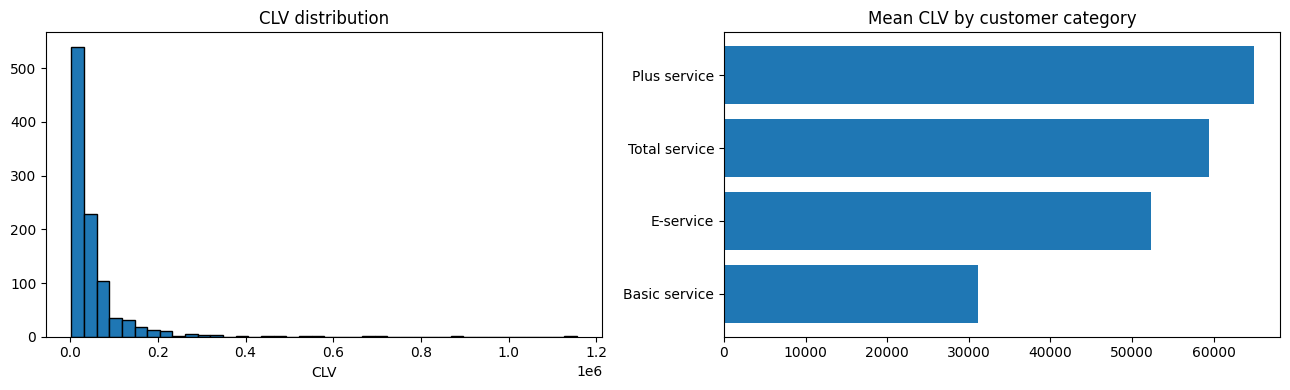

                       mean  count
custcat                           
Plus service   63244.366762    281
Total service  55175.837857    236
E-service      50243.000868    217
Basic service  27271.128653    266


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(seg_df["CLV"], bins=40, edgecolor="black")
axes[0].set_title("CLV distribution"); axes[0].set_xlabel("CLV")

mc = seg_df.groupby("custcat")["CLV"].mean().sort_values()
axes[1].barh(mc.index.astype(str), mc.values)
axes[1].set_title("Mean CLV by customer category")
plt.tight_layout(); plt.show()

seg_df["value_score"] = seg_df["CLV"] * (1 - seg_df["churn_prob_12m"])
print(seg_df.groupby("custcat")["value_score"]
      .agg(["mean", "count"]).sort_values("mean", ascending=False))

In [16]:
print(f"{'thr':>5} | {'at_risk':>7} | {'% base':>7}|"
    f"{'expected_loss':>14} | {'budget@30%':>11}")
for thr in [0.10, 0.20, 0.30, 0.40, 0.50]:
    ar = seg_df[seg_df["churn_prob_12m"] > thr]
    loss = (ar["churn_prob_12m"] * ar["CLV"]).sum()
    print(f"{thr:>5.2f} | {len(ar):>7} | {len(ar)/len(seg_df):>6.1%} | "
          f"${loss:>12,.0f} | ${loss*0.30:>9,.0f}")

  thr | at_risk |  % base| expected_loss |  budget@30%
 0.10 |     391 |  39.1% | $   1,903,665 | $  571,099
 0.20 |     198 |  19.8% | $   1,040,646 | $  312,194
 0.30 |      84 |   8.4% | $     439,365 | $  131,810
 0.40 |      37 |   3.7% | $     201,987 | $   60,596
 0.50 |      13 |   1.3% | $      83,758 | $   25,127


# Final Report

## Findings & Recommendations

### Factors driving churn

The final **LogNormal AFT model** (AIC 2942.4, concordance 0.784) identified nine significant drivers of subscriber lifetime. Reading time ratios `exp(β)`: **internet** is the single largest churn accelerator, internet customers' expected lifetime is **54% shorter** than non-internet customers (`exp(β) = 0.46`), **voice** plans cut lifetime by ~34% (`0.66`), each additional **education** level reduces lifetime by ~12% (`0.88`). On the loyalty side, **customer category** is the strongest stabilizer. Total/Plus/E-service subscribers live **2.5× to 3.3× longer** than Basic-service ones, **married** subscribers add ~57% lifetime (`1.57`), each year of **age** or of **address** stability adds ~4% (`1.03`–`1.04`). The high-risk subscriber is a **young, unmarried, mobile, well-educated Basic-service customer who has internet and voice add-ons**, the loyal one is **older, married, address-stable, on Total/Plus/E-service without those add-ons**.

### Most valuable segments, retention budget, and recommendations

A **valuable** customer is one with **high CLV combined with low 12-month churn risk**, formally `value_score = CLV × (1 − P(churn ≤ 12))`. Across the base, mean CLV is **$51,896** over a 60-month horizon at a 10% annual discount, with strong right skew (median $28,263, max $1.16M) - a small set of subscribers carries most of the value. By the value score, the most valuable segments are **Total-service and Plus-service customers aged 45+ who are married and address-stable**. At a 20% one-year churn-risk threshold, **198 of 1,000 subscribers (19.8%) are at risk**, carrying **$1.04M of expected revenue loss** if untreated. I recommend an **annual retention budget of ≈ $312K (30% of expected loss, ~$1,577 per at-risk customer)**, the remaining 70% is the expected save. Beyond money: (1) prioritize the highest-risk × highest-CLV deciles, not the longest list, (2) build a **proactive playbook around the early-tenure hazard peak** (the LogNormal hazard rises then falls), (3) **investigate the internet+voice combination**, it's the dominant churn driver and probably reflects a service or pricing problem worth fixing rather than just discounting around, (4) **upsell Basic-service customers** toward Total/Plus tiers, where survival is 2.5–3.3× longer and (5) **re-train the model quarterly** so the at-risk list reflects current behavior rather than last year's.